# Classical Machine Learning [CML]: Assignment

## 0. Assignment Metadata

### 0.0 Word Count

In [530]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}

    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())

    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f'{cell_type}, {counts[cell_type]}')

    print(f'total, {total}')

    if total > 75000:
        print('Too many characters in assignment submission (> 75,000)')
    else:
        print('Number of characters ok (< 75,000)')
    
count_chars('cml-assignment.ipynb')

code, 12389
markdown, 22701
raw, 0
other, 0
total, 35090
Number of characters ok (< 75,000)


### 0.1 Table of Contents

- [1. `dataset_1.csv`](#1-dataset_1csv)
    - [1.1 Introduction](#11-introduction)
    - [1.2 Load the Required Libraries](#12-load-the-required-libraries)
    - [1.3 Load the Data into a Dataframe](#13-load-the-data-into-a-dataframe)
    - [1.4 Clean the Data](#14-clean-the-data)
    - [1.5 Select Clustering Algorithms](#15-select-clustering-algorithms)
    - [1.6 DBSCAN](#16-dbscan)
    - [1.7 HDBSCAN](#17-hdbscan)
    - [1.8 OPTICS](#18-optics)
    - [1.9 Review the Results](#19-review-the-results)
- [2. `dataset_2.csv`](#2-dataset_2csv)
    - [2.1 Introduction](#21-introduction)
    - [2.2 Load the Required Libraries](#22-load-the-required-libraries)
    - [2.3 Load the Data into a Dataframe](#23-load-the-data-into-a-dataframe)
    - [2.4 Clean the Data](#24-clean-the-data)
    - [2.5 Select Clustering Algorithms](#25-select-clustering-algorithms)
    - [2.6 Spectral Clustering](#26-spectral-clustering)
    - [2.7 Birch](#27-birch)
    - [2.8 Gaussian Mixture Models](#28-gaussian-mixture-models)
    - [2.9 Review the Results](#29-review-the-results)
- [3. `dataset_3.csv`](#3-dataset_3csv)
    - [3.1 Introduction](#31-introduction)
    - [3.2 Load the Required Libraries](#32-load-the-required-libraries)
    - [3.3 Load the Data into a Dataframe](#33-load-the-data-into-a-dataframe)
    - [3.4 Clean the Data](#34-clean-the-data)
    - [3.5 Select Clustering Algorithms](#35-select-clustering-algorithms)
    - [3.6 DBSCAN](#36-dbscan)
    - [3.7 HDBSCAN](#37-hdbscan)
    - [3.8 Spectral Clustering](#38-spectral-clustering)
    - [3.9 Review the Results](#39-review-the-results)
- [4. `dataset_4.csv`](#4-dataset_4csv)
    - [4.1 Introduction](#41-introduction)
    - [4.2 Load the Required Libraries](#42-load-the-required-libraries)
    - [4.3 Load the Data into a Dataframe](#43-load-the-data-into-a-dataframe)
    - [4.4 Clean the Data](#44-clean-the-data)
    - [4.5 Select Clustering Algorithms](#45-select-clustering-algorithms)
    - [4.6 Spectral Clustering](#46-spectral-clustering)
    - [4.7 OPTICS](#47-optics)
    - [4.8 DBSCAN](#48-dbscan)
    - [4.9 Review the Results](#49-review-the-results)
- [A. Appendix](#a-appendix)
    - [A.1 References](#a1-references)

## 1. `dataset_1.csv`

### 1.1 Introduction

The following section will explore a number of different techniques to determine the optimum number of clusters for the dataset under observation, which is provided in `dataset_1.csv`.

### 1.2 Load the Required Libraries

Before we can perform any analysis on the dataset we first need to import the relevant **Python** libraries. 

In [445]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn import preprocessing, metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

- We import `pandas`, a python library which allows us to work with dataframes.
    - `pandas` also contains the `scatter_matrix` module, which we will use to derive any relationship between the different features present in the dataset.
- `sklearn` provides many machine learning algorithms and utility functions, including `preprocessing` for data standardisation and `KMeans` which uses an iterative process to cluster data.
- `numpy` is a popular library that is ideal for working with multi-dimensional arrays.
- Many plotting libraries, including:
    - `matplotlib.pyplot` for plotting graphs.
    - `seaborn` for plotting `pairplots`.
    - `missingno`for missing data identification.
    - `mpl_toolkits.mplot3d` and `plotly.express` for three-dimensional data visualisation.


### 1.3 Load the Data into a Dataframe

First, we read the dataset into `dataset_1` using the `read_csv()` method provided by `pandas`.

In [446]:
dataset_1 = pd.read_csv('CML_2026-04-27#3-dataset1.csv')

Then, we display the dataset:

In [447]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


### 1.4 Clean the Data

Before we can feed our dataset into any machine learning or data visualisation algorithm we must first ensure that all the data features are in the correct **format** and **standardised** appropriately. In addition, any **missing values** must be **removed** or **imputed**, depending on its effect on the overall model.

#### 1.4.1 Missing Data Visualisation

Lets first utilise `pandas`'s `isnull()` method to determine whether any of the features contain missing values:

In [448]:
print(f'Missing null counts = \n{dataset_1.isnull().sum()}')

Missing null counts = 
x    0
y    0
dtype: int64


We can also use the `matrix` provided by `missingno` to get a more visual idea of any potential missing datapoints:

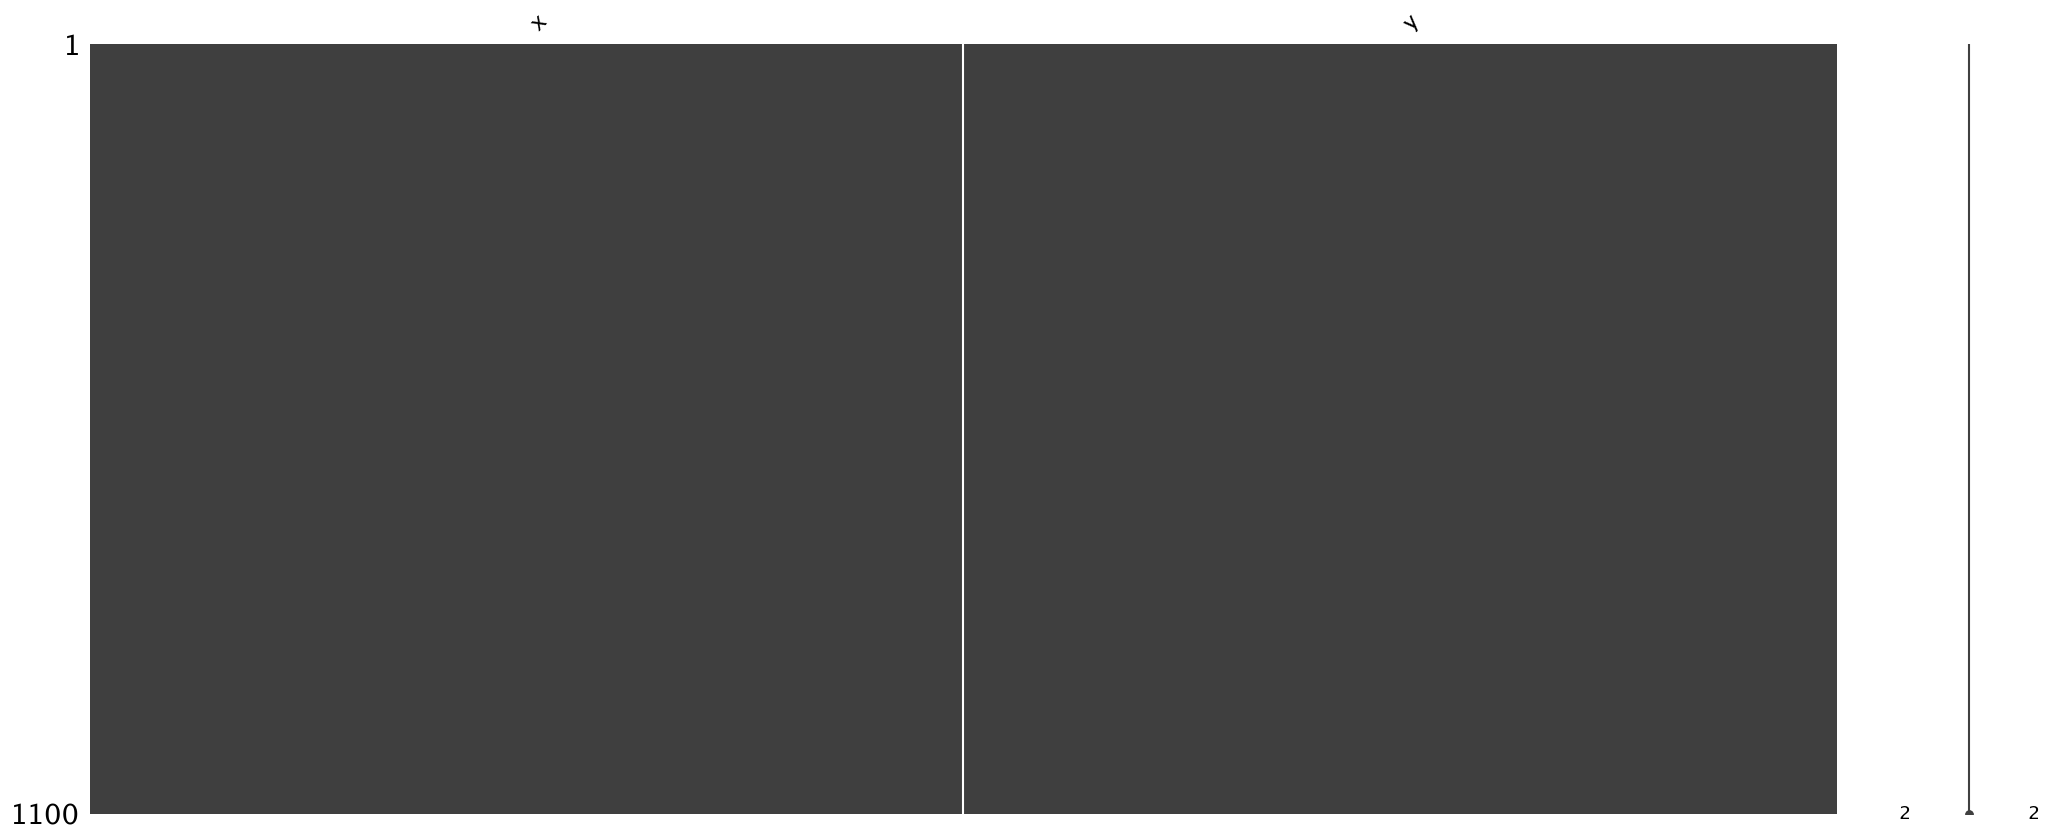

In [449]:
%matplotlib inline

msno.matrix(dataset_1)
plt.show()

*<center>Figure 1: Missing Data Visualisation</center>*

As a result, we can be reasonably confident that none of the features, `x` or `y`, contain any `null` values.

#### 1.4.2 Format Decimal Places

Another technique to clean the data would be to limit the number of decimal places in each of the features. However, we do not want to lose useful information about the underlying data in the process.

If we take another look at the data:

In [450]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


The features `x` and `y` resemble coordinates, and the more decimal places there are in a set of coordinates, the more precise the coordinates will be.[<sup>1</sup>](#a1-references)

However, if we set the number of decimal places to `5`, we should retain an accuracy to `1.11 meters` in the underlying data whilst also reducing the computational power and execution time of the underlying model.

In [451]:
pd.set_option('display.float_format', '{:.5f}'.format)

In [452]:
dataset_1

,x,y
0,0.46544,0.94983
1,0.68888,-0.44487
2,1.83610,0.12347
3,0.75223,0.70726
4,-0.32186,0.86340
...,...,...
1095,-3.26696,-1.06445
1096,-3.31567,1.45050
1097,-2.46885,-2.36481
1098,-2.32953,2.66412


#### 1.4.3 Standardise the Data

Before we feed the dataset into a model to be trained and tested, **standardisation** is an often useful technique to improve the efficiency of machine learning algorithms by scaling them to a width that is easier to digest by the underlying model but also retains the structure of the model without removing useful information.

Let's pass our dataframe into the `scale()` method provided by `sklearn`'s `preprocessing` module:

In [453]:
standardised_dataset_1 = preprocessing.scale(dataset_1)
standardised_dataset_1_df = pd.DataFrame(standardised_dataset_1, columns=dataset_1.columns)
standardised_dataset_1_df

,x,y
0,0.10535,0.48284
1,0.23013,-0.32286
2,0.87078,0.00546
3,0.26550,0.34271
4,-0.33431,0.43291
...,...,...
1095,-1.97897,-0.68079
1096,-2.00617,0.77207
1097,-1.53327,-1.43199
1098,-1.45547,1.47317


### 1.5 Select Clustering Algorithms

#### 1.5.1 Visualise the Data

Now, let's utilise the `scatter_matrix` method to visualise the relationship between `x` and `y`, as well as illustrate the distribution of the two features

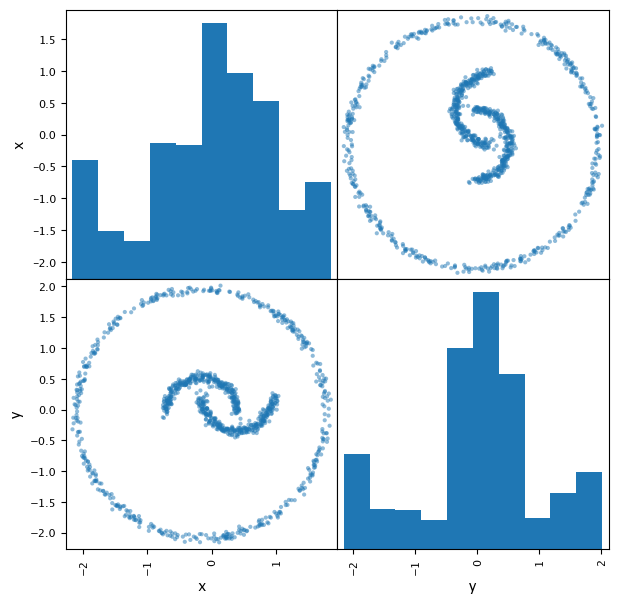

In [454]:
%matplotlib inline

scatter_matrix(standardised_dataset_1_df, figsize=(7, 7))

plt.show()

*<center>Figure 2: Scatter Matrix Visualisation</center>*

We can definitely see a natural clustering here. Let's look at the different clustering algorithms provided by `sklearn.cluster` so we can get a better idea which is best suited for our dataset.

#### 1.5.2 Select Clustering Algorithms

![](./images/clustering-algorithms.png)

*<center>Figure 3: `sklearn` Clustering Algorithms[<sup>2</sup>](#a1-references)</center>*

If we look through the different clustering algorithms referenced in **Figure 3**, we can identify the following as being contenders:
- `DBSCAN`.
- `HDBSCAN`.
- `OPTICS`.

The reason for the selection is by reflecting on the data visualisation of our dataset illustrated in **Figure 2**. We are looking for a solution that can appropriately cluster the outer circle and inner shapes as reflected by the shape of our dataset. If we evaluate the first two rows of **Figure 3**, we can see that our selected options seem suited to appropriately cluster our dataset, based on the shapes and resulting splits demonstrated.

> Note: While `Spectral Clustering` also reflects the dataset, the execution time is significantly higher and requires a different method to evaluate performance from the rest, so is excluded from this report.

### 1.6 DBSCAN

#### 1.6.1 Build the Model

First, let's define a `dbscan_model()` method which takes in the dataframe and clusters the data using the `DBSCAN` algorithm.

In [562]:
def dbscan_model(X):
    dbscan = DBSCAN()
    dbscan.fit(X)

    labels = dbscan.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return dbscan

dbscan = dbscan_model(standardised_dataset_1_df)

labels = [0 0 0 ... 1 1 1]
label_set = {np.int64(0), np.int64(1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 0


The method first calls the `DBSCAN()` method to instantiate the library object, and calls the `.fit()` method to train the model on the input data.

After fitting, the function extracts and inspects the cluster labels, and then converts those labels to a `set` to identify **how many unique clusters exist**. It then converts those labels to a `list` and displays the first ten rows, giving a sense of early clustering patterns. 

Finally, the function then counts how many noise points (-1) values exist using the `.count(-1)` method. 

The output of running the `dbscan_model()` method, in which we pass our dataframe, `standardised_dataset_1_df`, indicates that it has identified two clusters, `0` and `1` with `no noise points`.

#### 1.6.2 Generate Silhouette Score

In [563]:
db_labels = np.ravel(dbscan.labels_).astype(int)

print(f'DBSCAN Score: {silhouette_score(standardised_dataset_1_df, db_labels)}')

DBSCAN Score: 0.27060252973364857


The `astype(int)` method turns our `labels` into `integer` values which are required to generate the `silhouette score`.

Finally, the `silhouette_score()` method takes in the dataframe and the `labels` and generates a score.

It's worth nothing that the score is closer to `1`, which is a positive sign!

#### 1.6.3 Visualise the Data

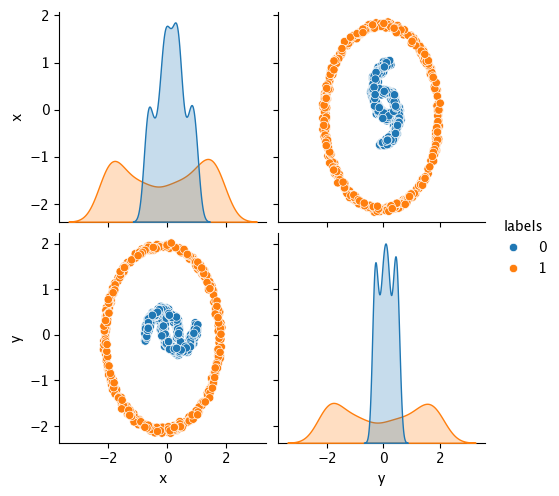

In [564]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = dbscan.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 4: `DBSCAN` Pairplot</center>*

When we plot the `pairplot`, we can see that it separates the outer circle well from the inner structures. However, it seems to have grouped the two inner structures together into a single cluster.

### 1.7 HDBSCAN

#### 1.7.1 Build the Model

Let's now take a look at the `HDSCAN` model.

In [458]:
def hdbscan_model(X):
    hdbscan = HDBSCAN()
    hdbscan.fit(X)

    labels = hdbscan.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return hdbscan

hdbscan = hdbscan_model(standardised_dataset_1_df)

labels = [1 2 2 ... 0 0 0]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
label_list[0:10] = [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2)]
noise_point_count = 1


/Users/alexrandall/Documents/Oxford/Coursework/CML/Assignment/cml-assignment/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


We use a synactically similar method here to `DBSCAN`, however we are creating a `HDBSCAN` which uses a more sophisticated technique by allocating a dynamic `epsilon` parameter and building a hierarchical clustering tree.[<sup>3</sup>](#a1-references)

#### 1.7.2 Generate Silhouette Score

In [459]:
hdb_labels = np.ravel(hdbscan.labels_).astype(int)

print(f'HDBSCAN Score: {silhouette_score(standardised_dataset_1_df, hdb_labels)}')

HDBSCAN Score: -0.14212058855056256


We see a lower silhouette score, as its slightly in the negative.

#### 1.7.3 Visualise the Data

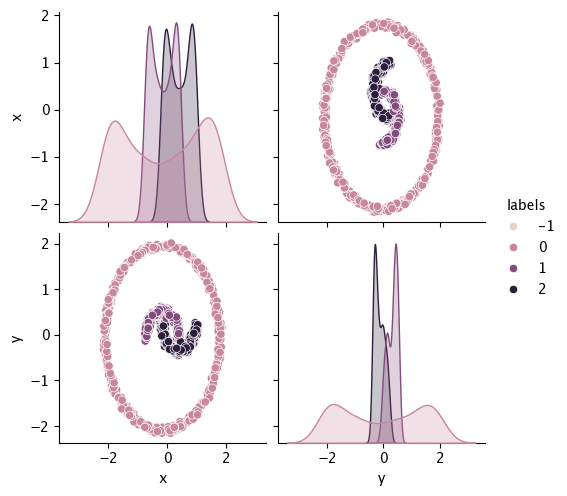

In [460]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = hdbscan.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 5: `HDBSCAN` Pairplot</center>*

`Figure 5` indicates that it seems to be the best fit for the data, however! We can see that it has split the data into four separate clusters, one for the outer circle, two for the inner structures, and some noise.

### 1.8 OPTICS

#### 1.8.1 Build the Model

Let's try building the `OPTICS` model.

In [461]:
def optics_model(X):
    optics = OPTICS(min_samples=50)
    optics.fit(X)

    labels = optics.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return optics

optics = optics_model(standardised_dataset_1_df)

labels = [-1  1  1 ... -1 -1  3]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
label_list[0:10] = [np.int64(-1), np.int64(1), np.int64(1), np.int64(-1), np.int64(-1), np.int64(0), np.int64(-1), np.int64(1), np.int64(-1), np.int64(1)]
noise_point_count = 532


We build the `optics_model()` in much the same way as we built the previous two, by instantiating the model object, training the model, and then transforming the response to show the labels, the different clusters, and the noise.

Immediately we can see that it has clustered the underlying dataset into five clusters in addition to a `noise` cluster, which contains 532 points!

#### 1.8.2 Generate Silhouette Score

In [462]:
optics_labels = np.ravel(optics.labels_).astype(int)

print(f'OPTICS Score: {silhouette_score(standardised_dataset_1_df, optics_labels)}')

OPTICS Score: 0.07572251599813357


However, the score is much higher than `HDBSCAN`.

#### 1.8.3 Visualise the Data

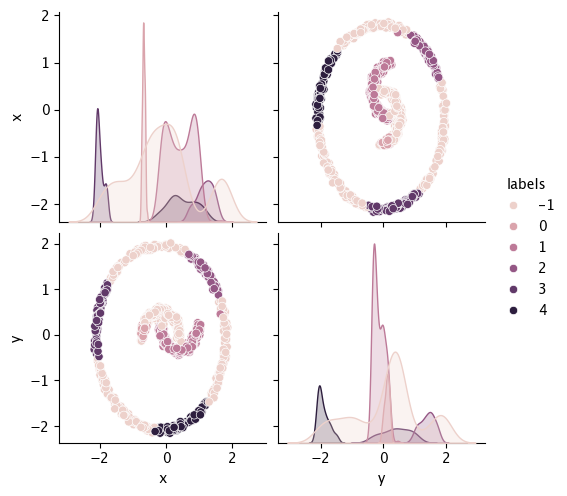

In [463]:
X = standardised_dataset_1_df.copy(['x', 'y']).copy()
X['labels'] = optics.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 6: `OPTICS` Pairplot</center>*

And we can see from `Figure 6` that it has indeed created five clusters and a noise cluster, and it has perhaps overfitted and created more clusters than is represented by the underlying dataset, despite the higher score.

### 1.9 Review the Results

`Figure 5` in the previous section demonstrated that `HDBSCAN` fits the underlying dataset the most, but we need to perform some additional validation before we can be sure, especially considering it produced the lowest silhouette score.

What we do have are the cluster labels, but we can also utilise the `fit_predict()` method to assign each member of the dataset to a cluster:

In [464]:
y_hdbscan = hdbscan.fit_predict(standardised_dataset_1_df)

print(f'y_hdbscan[0:20] = {y_hdbscan[0:20]}')

y_hdbscan[0:20] = [1 2 2 1 1 1 1 2 1 2 1 1 1 2 2 1 1 1 1 1]


/Users/alexrandall/Documents/Oxford/Coursework/CML/Assignment/cml-assignment/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


If we print the results of slicing through `y_hdbscan` you can see the cluster assignments for the first ten rows of the underlying dataset.

In [465]:
print(dataset_1[y_hdbscan==0][0:10])

           x        y
600  0.61083 -3.45493
601 -3.21021  1.30793
602  2.19692 -2.76311
603 -1.11064 -3.36145
604  2.94485  2.01742
605  3.48102 -0.55117
606  0.27201 -3.50995
607  0.84246 -3.52041
608  2.40585  2.40337
609 -3.42101  1.15532


We can use the `y_dbscan` index to view the first ten rows of the first cluster (where the `label` is 0). 

#### 1.9.1 Identifying Cluster Centers

In [466]:
coordinate_clusters = standardised_dataset_1_df.copy()
coordinate_clusters['y_hdbscan'] = y_hdbscan
coordinate_clusters

,x,y,y_hdbscan
0,0.10535,0.48284,1
1,0.23013,-0.32286,2
2,0.87078,0.00546,2
3,0.26550,0.34271,1
4,-0.33431,0.43291,1
...,...,...,...
1095,-1.97897,-0.68079,0
1096,-2.00617,0.77207,0
1097,-1.53327,-1.43199,0
1098,-1.45547,1.47317,0


In addition, we can view the data rows along with their corresponding cluster assignment.

In [467]:
cluster_means = coordinate_clusters.groupby(['y_hdbscan']).mean().round(1)
cluster_means

,x,y
y_hdbscan,,
-1,-0.20000,0.30000
0,-0.20000,-0.10000
1,-0.20000,0.30000
2,0.40000,-0.10000


As well as the `mean` of each of the features for each of the clusters.

#### 1.9.2 Visualising the Clusters

Whilst viewing the data can provide insights, for coordinate data it is a lot more relevant to visualise the data to ensure it has been clustered appropriately. By utilising the `scatter` method provided by `matplotlib.pyplot` and providing a cluster of the original dataset for each dimension of the plot, we can plot the graph as below.

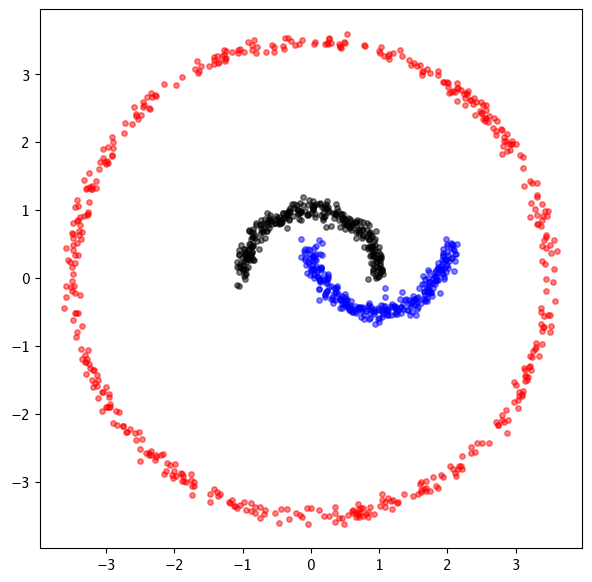

In [468]:
plt.figure(figsize=(7, 7))
plt.scatter(dataset_1[y_hdbscan==0]['x'], dataset_1[y_hdbscan==0]['y'], s=15, c='red', alpha=.5)
plt.scatter(dataset_1[y_hdbscan==1]['x'], dataset_1[y_hdbscan==1]['y'], s=15, c='black', alpha=.5)
plt.scatter(dataset_1[y_hdbscan==2]['x'], dataset_1[y_hdbscan==2]['y'], s=15, c='blue', alpha=.5)
plt.show()

*<center>Figure 7: `HDBSCAN` Scatter Plot</center>*

Whilst the `silhouette score` is an incredibly useful technique to determine the effectiveness of the clustering technique, it is ineffective in some instances. By visualising the data and trying different algorithms to cluster the underlying dataset, such as `DBSCAN`, `HDBSCAN`, and `OPTICS`, we were able to identify `HDBSCAN` as being the optimum clustering technique for this particular dataset.

## 2. `dataset_2.csv`

### 2.1 Introduction

In this section we will explore a number of techniques to determine the optimum number of clusters pertaining to the underlying dataset provided in `dataset_2.csv`.

### 2.2 Load the Required Libraries

In [469]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn import preprocessing, metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

Similar to the previous section, we are aiming to ensure we import the relevant python libraries available which can be utilised to perform the clustering operations. The notable difference in this case is that we are importing a different selection of **clustering algorithms**.

### 2.3 Load the Data into a Dataframe

First, we read the dataset into `dataset_2` using the `read_csv()`.

In [470]:
dataset_2 = pd.read_csv('CML_2026-04-27#4-dataset2.csv')

And display the dataset as follows:

In [471]:
dataset_2

,x,y,z
0,-1.62372,-1.46167,0.12779
1,-1.55718,-2.70196,0.34007
2,3.52793,3.99231,0.06923
3,1.70383,1.67175,-0.24111
4,3.18502,2.68493,-0.42757
...,...,...,...
1195,0.73780,5.17344,8.43337
1196,0.98108,-3.00289,-1.67912
1197,1.47980,-5.04501,-3.43723
1198,1.02709,-0.40067,2.18682


### 2.4 Clean the Data

Similar to the previous section, we need to ensure that the data has been checked for **missing values**, formatted in terms of **decimal places**, as well as **standardised** to fit the models being tested.

#### 2.4.1 Missing Data Visualisation

In [472]:
print(f'Missing null counts = \n{dataset_2.isnull().sum()}')

Missing null counts = 
x    0
y    0
z    0
dtype: int64


By utilising the `isnull()` method we can see that there are no missing values in our dataset.

#### 2.4.2 Format Decimal Places

We can also make sure to format the decimal places to `5` for ease of computation.

In [473]:
pd.set_option('display.float_format', '{:.5f}'.format)

In [474]:
dataset_2

,x,y,z
0,-1.62372,-1.46167,0.12779
1,-1.55718,-2.70196,0.34007
2,3.52793,3.99231,0.06923
3,1.70383,1.67175,-0.24111
4,3.18502,2.68493,-0.42757
...,...,...,...
1195,0.73780,5.17344,8.43337
1196,0.98108,-3.00289,-1.67912
1197,1.47980,-5.04501,-3.43723
1198,1.02709,-0.40067,2.18682


#### 2.4.3 Standardise the Data

Finally, the dataframe can be standardised by urilising the `preprocessing` module provided by `sklearn`:

In [475]:
standardised_dataset_2 = preprocessing.scale(dataset_2)
standardised_dataset_2_df = pd.DataFrame(standardised_dataset_2, columns=dataset_2.columns)
standardised_dataset_2_df

,x,y,z
0,-1.09657,-0.74777,-0.30678
1,-1.06966,-1.16334,-0.19734
2,0.98682,1.07965,-0.33697
3,0.24913,0.30211,-0.49697
4,0.84814,0.64159,-0.59310
...,...,...,...
1195,-0.14154,1.47539,3.97525
1196,-0.04315,-1.26417,-1.23835
1197,0.15853,-1.94841,-2.14476
1198,-0.02455,-0.39227,0.75477


### 2.5 Select Clustering Algorithms

Now, that we have our data cleansed, let's call the `scatter_matrix` method to get a visual representation of the dataset's feature relationships.

#### 2.5.1 Visualise the Data

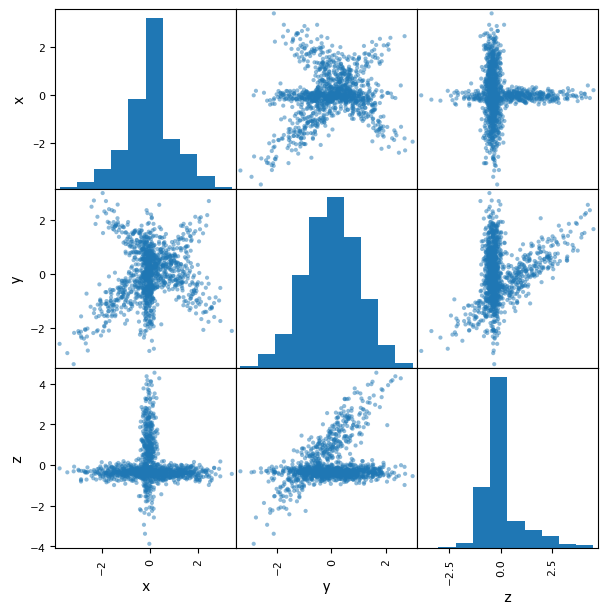

In [476]:
%matplotlib inline

scatter_matrix(standardised_dataset_2_df, figsize=(7, 7))

plt.show()

*<center>Figure 8: Scatter Matrix Visualisation</center>*

Looking at `Figure 8` we can definitely see a few linear relationships between the different features `x`, `y`, and `z`. 

If we compare the general shape of the relationships with the clustering algorithms illustrated in `Figure 3`, we can see some similarities fourth row. Looking at how the different algorithms cluster the data in the fourth row, we can identify the following as being contenders:

- `Spectral Clustering`.
- `BIRCH`.
- `Gaussian Mixture Models`.

### 2.6 Spectral Clustering

#### 2.6.1 Determine Number of Clusters

Since `Spectral Clustering` expects the `n_clusters` parameters to be set, let's loop through and set the `silhouette` score to determine the optimal number of clusters for this algorithm.

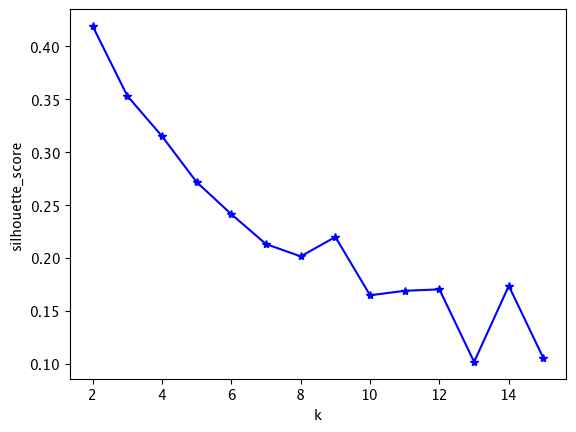

In [477]:
%matplotlib inline

def sp_silhouette(X, clusters):
    K = range(2, clusters+1)
    score = []
    for k in K:
        sp_cluster = SpectralClustering(n_clusters=k)
        sp_cluster.fit(X)
        labels = sp_cluster.labels_
        score.append(metrics.silhouette_score(X, labels, metric='euclidean'))

    plt.plot(K, score, 'b*-')
    plt.xlabel('k')
    plt.ylabel('silhouette_score')

    plt.show()

sp_silhouette(standardised_dataset_2_df, 15)

*<center>Figure 9: `SpectralClustering` Number of Clusters</center>*

`Figure 9` illustates a sharp drop after `k = 2`, indicating that `2` is the optimum number of clusters for this algorithm.

#### 2.6.2 Build the Model

Now, let's build the model.

In [590]:
def sp_clustering_model(X):
    sp_model = SpectralClustering(n_clusters=2)
    sp_model.fit(X)

    labels = sp_model.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return sp_model

sp_model = sp_clustering_model(standardised_dataset_2_df)

labels = [1 1 1 ... 1 1 1]
label_set = {np.int32(0), np.int32(1)}
label_list[0:10] = [np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1)]
noise_point_count = 0


We fit the `n_clusters` to be `2` as a result of the optimum number of clusters provided in the previous section, and can see the algorithm has split the dataset into two distinct clusters.

#### 2.6.3 Generate Scores

In [479]:
spectral_labels = sp_model.fit_predict(standardised_dataset_2_df)

print(f'Silhouette Score: {silhouette_score(standardised_dataset_2_df, spectral_labels):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(standardised_dataset_2_df, spectral_labels):.4f}')


Silhouette Score: 0.4194
Davies-Bouldin Index: 0.7050


We use an additional metric, the `Davies-Bouldin Index`, to determine the average similarity measure of each cluster within its most similar cluster[<sup>4</sup>](#a1-references). 

The minimum score is `zero`, with **lower** values indicating better clustering.

#### 2.6.4 Visualise the Data

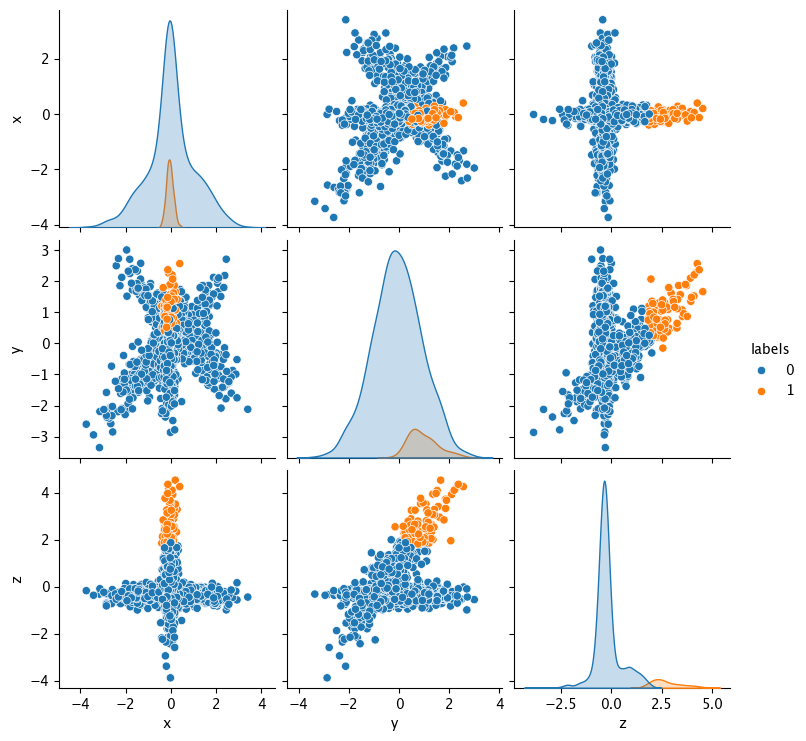

In [480]:
X = standardised_dataset_2_df.copy(['x', 'y', 'z']).copy()
X['labels'] = sp_model.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 10: `SpectralClustering` Pairplot</center>*

`Figure 10` illustrates an unfit algorithm for our underlying dataset, as it doesn't seem to be clustering the individual Gaussians separately.

### 2.7 Birch

#### 2.7.1 Determine Number of Clusters

Similar to the previous section, let's use the `Birch` algorithm to determine the optimal number of clusters.

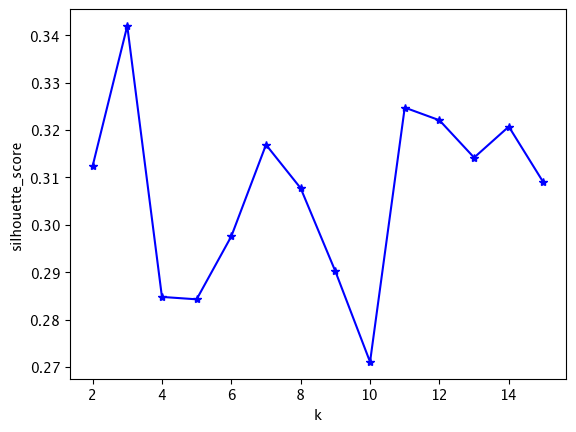

In [481]:
%matplotlib inline

def birch_silhouette(X, clusters):
    K = range(2, clusters+1)
    score = []
    for k in K:
        birch = Birch(n_clusters=k)
        birch.fit(X)
        labels = birch.labels_
        score.append(metrics.silhouette_score(X, labels, metric='euclidean'))

    plt.plot(K, score, 'b*-')
    plt.xlabel('k')
    plt.ylabel('silhouette_score')

    plt.show()

birch_silhouette(standardised_dataset_2_df, 15)

*<center>Figure 11: `BIRCH` Number of Clusters</center>*

We can see here that the algorithm correctly identifies the number of clusters to be `3` (based on visual inspection of the scatter matrix illustrated in `Figure 8`).

#### 2.7.2 Build the Model

Let's look at building the `BIRCH` model.

In [482]:
def birch_model(X):
    birch = Birch(n_clusters=3)
    birch.fit(X)

    labels = birch.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return birch

birch = birch_model(standardised_dataset_2_df)

labels = [1 1 0 ... 1 0 1]
label_set = {np.int64(0), np.int64(1), np.int64(2)}
label_list[0:10] = [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
noise_point_count = 0


Sure enough, `label_set` contains three distinct cluster indexes, with no noise being identified in the model.

#### 2.7.3 Generate Scores

In [483]:
birch_labels = birch.fit_predict(standardised_dataset_2_df)

print(f'Silhouette Score: {silhouette_score(standardised_dataset_2_df, birch_labels):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(standardised_dataset_2_df, birch_labels):.4f}')

Silhouette Score: 0.3420
Davies-Bouldin Index: 0.9507


- The `Silhouette Score` is `0.3420` compared to `0.4194` in the previous section.
- The `Davies-Bouldin Index` is `0.9507` compared to `0.7050` in the previous section.

This indicates that the algorithm might be a poorer fit than `Spectral Clustering`. 

Let's visualise the data to validate this.

#### 2.7.4 Visualise the Data

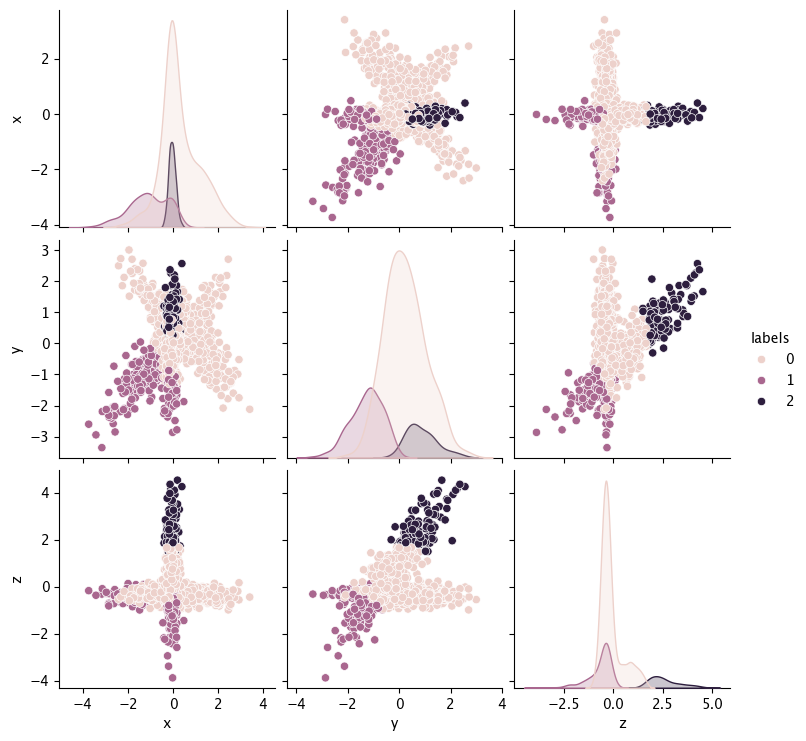

In [484]:
X = standardised_dataset_2_df.copy(['x', 'y', 'z']).copy()
X['labels'] = birch.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 12: `BIRCH` Pairplot</center>*

Sure enough, we can see from `Figure 12` that the algorithm is also a poor fit for the dataset.

### 2.8 Gaussian Mixture Models

Now, let's use the `GaussianMixture` library provided by `sklearn.mixture` to cluster the data.

#### 2.8.1 Determine Number of Clusters

We use a slightly different metric here to determine the number of clusters. 

- `bic()`: **Bayes Information Criterion**.
- `aic()`: **Akaike Information Criterion**.

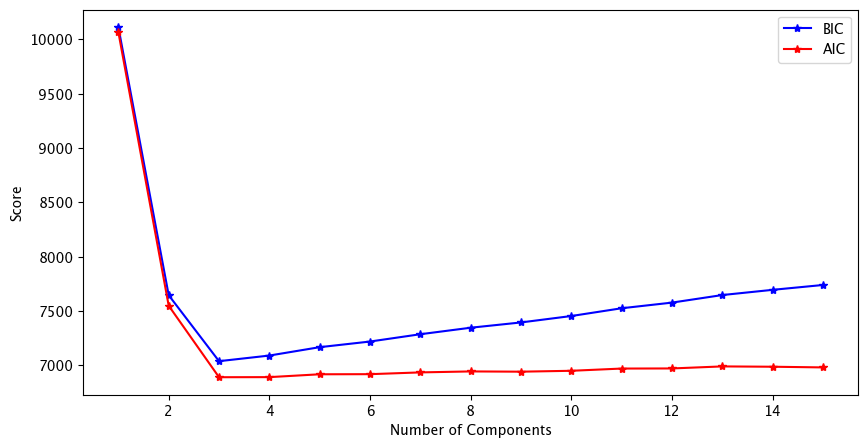

In [485]:
def find_optimal_gmixture_components(X, max_components=15):
    bic_scores = []
    aic_scores = []
    K = range(1, max_components + 1)
    
    for k in K:
        gmixture = GaussianMixture(n_components=k)
        gmixture.fit(X)
        bic_scores.append(gmixture.bic(X))
        aic_scores.append(gmixture.aic(X))
    
    plt.figure(figsize=(10, 5))
    plt.plot(K, bic_scores, 'b*-', label='BIC')
    plt.plot(K, aic_scores, 'r*-', label='AIC')
    plt.xlabel('Number of Components')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

optimal_components = find_optimal_gmixture_components(standardised_dataset_2_df, max_components=15)

*<center>Figure 13: `GMM` Number of Components</center>*

Using the two metrics outlined above, we plot the number of `components` versus their BIC and AIC scores to determine that `3` is in fact the optimum number of clusters for this algorithm.

#### 2.8.2 Build the Model

In [486]:
def gmixture_model(X):
    gmixture = GaussianMixture(n_components=3)
    gmixture.fit(X)

    return gmixture

gmixture = gmixture_model(standardised_dataset_2_df)

For the `gmixture_model`, we pass in the `n_components` that was determined in the previous section and call the method using our standardised dataset.

#### 2.8.3 Generate Scores

In [487]:
print(f'AIC Score: {gmixture.aic(standardised_dataset_2_df):.2f}')
print(f'BIC Score: {gmixture.bic(standardised_dataset_2_df):.2f}')

AIC Score: 6892.03
BIC Score: 7039.64


While not consistent with the other two algorithm and thus not useful in terms of performance comparison between the other two algorithms, the BIC and AIC scores are used to determine the `score` of Gaussian Mixture Models.

Since the lower the score the better, the scores returned from the algorithm don't seem to indicate a good fit for the underlying dataset.

#### 2.8.4 Visualise the Data

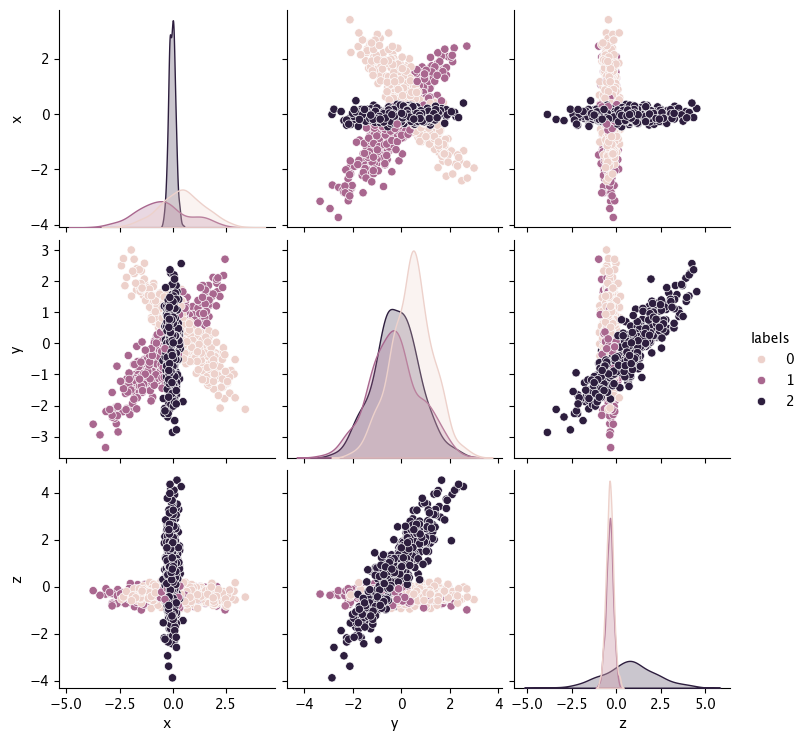

In [488]:
X = standardised_dataset_2_df.copy(['x', 'y', 'z']).copy()
gmixture_labels = gmixture.predict(standardised_dataset_2_df)
X['labels'] = gmixture_labels
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 14: `GMM` Pairplot</center>*

However, when we plot pairplot as illustrated in `Figure 14`, we can see that it actually splits the data appropriately and is the best contender for the best split so far.

### 2.9 Review the Results

#### 2.9.1 Visualising the Clusters

Let's verify this by visualising the data in three dimensions.

In [489]:
%matplotlib inline

plot_df = pd.DataFrame({
    'x': dataset_2['x'],
    'y': dataset_2['y'],
    'z': dataset_2['z'],
    'cluster': gmixture_labels.astype(str)
})

fig = px.scatter_3d(plot_df, x='x', y='y', z='z', 
                color='cluster', color_discrete_sequence=['red', 'black', 'blue'], 
                height=600, width=700)
fig.update_traces(marker=dict(size=3))
fig.show()

*<center>Figure 15: `GMM` 3D Visualisation</center>*

When we utilise `plotly` to build a `3D` representation of the underlying dataset using the clusters determined by the Gaussian Mixture Model, we can further validate that the algorithm is the best fit for the underlying data.

## 3. `dataset_3.csv`

### 3.1 Introduction

Let's explore the dataset provided in `dataset_3.csv`.

### 3.2 Load the Required Libraries

In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn import preprocessing, metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, HDBSCAN, SpectralClustering
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

### 3.3 Load the Data into a Dataframe

We start by loading the `csv` file into a dataframe.

In [491]:
dataset_3 = pd.read_csv('CML_2026-04-27#5-dataset3.csv')
dataset_3

,x,y
0,-2.23502,0.34899
1,-0.77287,2.48596
2,4.56656,-3.41543
3,-2.56882,-5.02684
4,7.10631,1.06634
...,...,...
2115,0.75919,-11.30610
2116,0.92779,-10.77979
2117,1.05568,-11.15934
2118,0.82860,-10.80926


We can see that our underlying dataset has two features, `x` and `y`, with `2120` rows of data.

### 3.4 Clean the Data

#### 3.4.1 Missing Data Visualisation

In [492]:
print(f'Missing null counts = \n{dataset_3.isnull().sum()}')

Missing null counts = 
x    0
y    0
dtype: int64


When we call the `isnull()` method on `dataset_3` we can see that for each feature there are `0` missing values.

#### 3.4.2 Format Decimal Places

In [493]:
pd.set_option('display.float_format', '{:.5f}'.format)

We also format the number of decimal places to `5` for ease of computation.

In [494]:
dataset_3

,x,y
0,-2.23502,0.34899
1,-0.77287,2.48596
2,4.56656,-3.41543
3,-2.56882,-5.02684
4,7.10631,1.06634
...,...,...
2115,0.75919,-11.30610
2116,0.92779,-10.77979
2117,1.05568,-11.15934
2118,0.82860,-10.80926


#### 3.4.3 Standardise the Data

Finally, let's standardise the data similar to the previous sections by calling the `scale()` method exposed by the `preprocessing` library.

In [495]:
standardised_dataset_3 = preprocessing.scale(dataset_3)
standardised_dataset_3_df = pd.DataFrame(standardised_dataset_3, columns=dataset_3.columns)
standardised_dataset_3_df

,x,y
0,-0.56186,0.02571
1,-0.19828,0.54708
2,1.12945,-0.89271
3,-0.64487,-1.28585
4,1.76100,0.20073
...,...,...
2115,0.18269,-2.81783
2116,0.22462,-2.68943
2117,0.25642,-2.78203
2118,0.19995,-2.69662


### 3.5 Select Clustering Algorithms

Now that our data is reasonably clean, let's call the `scatter_matrix` function so we can visualise the relationship between `x` and `y`.

#### 3.5.1 Visualise the Data

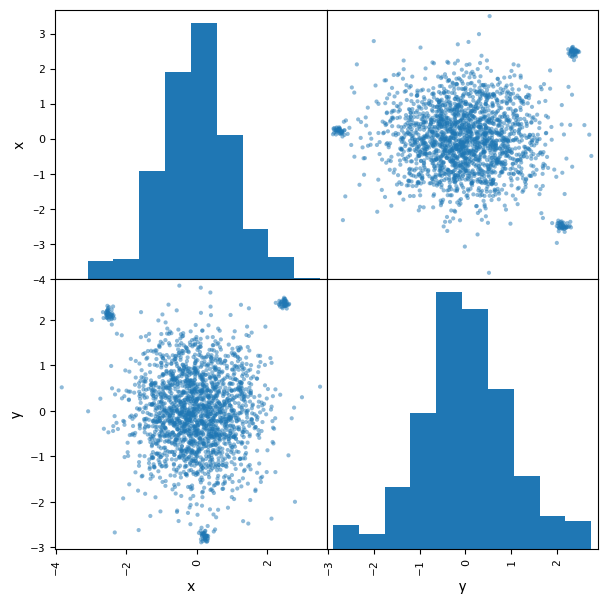

In [496]:
%matplotlib inline

scatter_matrix(standardised_dataset_3_df, figsize=(7, 7))

plt.show()

*<center>Figure 16: Scatter Matrix Visualisation</center>*

`Figure 16` illustrates the relationships between `x` and `y`. Looking at the shapes we can see a large blob in the middle surrounded by three small blobs. We want to identify a clustering algorithm that can appropriately split the data as represented in the scatter matrix. The following were identified as contenders:

- `DBSCAN`
- `HDBSCAN`
- `Spectral Clustering`

### 3.6 DBSCAN

#### 3.6.1 Build the Model

In [497]:
dbscan_3 = dbscan_model(standardised_dataset_3_df)

labels = [0 0 0 ... 0 0 0]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 13


We start by calling the `dbscan_model()` we created in [Setion 1.6](#16-dbscan), this time storing it in `dbscan_3`.

#### 3.6.2 Generate Silhouette Score

In [498]:
dbscan_3_labels = np.ravel(dbscan_3.labels_).astype(int)

print(f'DBSCAN Score: {silhouette_score(standardised_dataset_3_df, dbscan_3_labels)}')

DBSCAN Score: 0.42329486151246043


The `silhouette score` is calculated to be `0.42`, which indicates a fairly good degree of separation.

#### 3.6.3 Visualise the Data

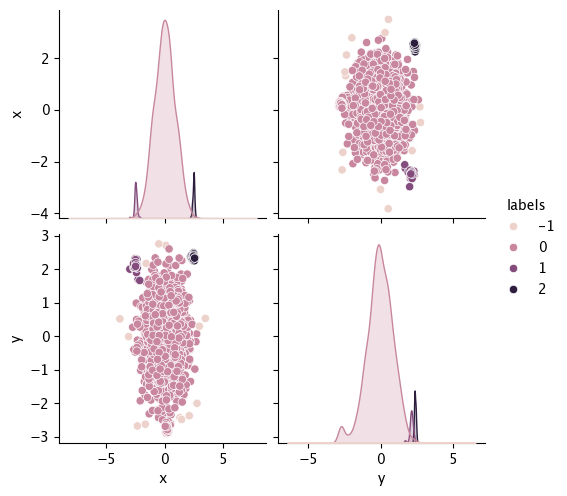

In [499]:
X = standardised_dataset_3_df.copy(['x', 'y']).copy()
X['labels'] = dbscan_3.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 17: `DBSCAN` Pairplot</center>*

And we can see that it split the group into three clusters. It seems fairly good, but it has allocated one of the blobs as noise! Let's keep exploring.

### 3.7 HDBSCAN

#### 3.7.1 Build the Model

Now, let's build a `HDBSCAN` model using the `hdbscan_model()` method created in [Section 1.7](#17-hdbscan).

In [501]:
hdbscan_3 = hdbscan_model(standardised_dataset_3_df)

labels = [1 1 1 ... 1 1 1]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
label_list[0:10] = [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
noise_point_count = 21


/Users/alexrandall/Documents/Oxford/Coursework/CML/Assignment/cml-assignment/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


#### 3.7.2 Generate Silhouette Score

In [502]:
hdbscan_3_labels = np.ravel(hdbscan_3.labels_).astype(int)

print(f'HDBSCAN Score: {silhouette_score(standardised_dataset_3_df, hdbscan_3_labels)}')

HDBSCAN Score: 0.4208382905488253


The `silhouette score` is quite close to that generated by the `DBSCAN` model.

#### 3.7.3 Visualise the Data

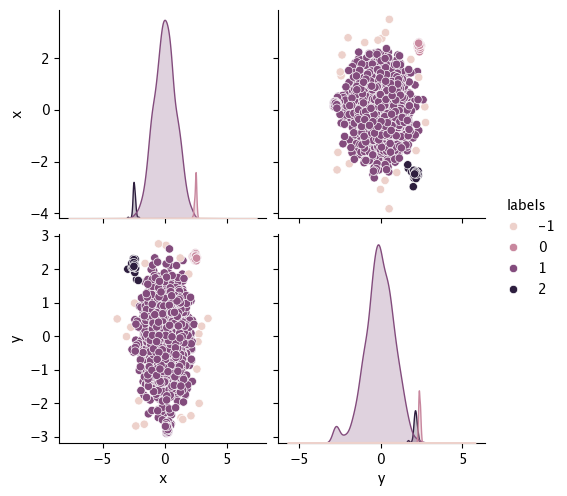

In [503]:
X = standardised_dataset_3_df.copy(['x', 'y']).copy()
X['labels'] = hdbscan_3.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 18: `HDBSCAN` Pairplot</center>*

`Figure 18` illustrates a slightly better fit than that generated by the `DBSCAN` model. It seems to more accurately reflect the noise. However, the bottom and middle groups are still clustered into a single group.

### 3.8 Spectral Clustering

Now let's explore using the `Spectral Clustering` algorithm to cluster our data. Since the function expects the `n_clusters` parameter to be set, let's pass in `n_clusters` to be `4`. This is to be consistent with the visual representation we are expecting to match the central blob as well as the three sub-blobs.

#### 3.8.1 Build the Model

In [594]:
def sp_clustering_model(X):
    sp_model = SpectralClustering(n_clusters=4)
    sp_model.fit(X)

    labels = sp_model.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return sp_model

sp_model_3 = sp_clustering_model(standardised_dataset_3_df)

labels = [0 0 0 ... 3 3 3]
label_set = {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
label_list[0:10] = [np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0)]
noise_point_count = 0


We can see from the output generated from the `sp_clustering_model()` method that the model has generated four groups and has identified no noise.

#### 3.8.2 Generate Scores

In [529]:
spectral_3_labels = sp_model_3.fit_predict(standardised_dataset_3_df)

print(f'Silhouette Score: {silhouette_score(standardised_dataset_3_df, spectral_3_labels):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(standardised_dataset_3_df, spectral_3_labels):.4f}')

Silhouette Score: 0.3390
Davies-Bouldin Index: 0.4289


Furthermore, the `silhouette score` is slightly lower than that of the other two algoriths, indicating that it is slightly less separated. The reverse is true with the `Davies-Bouldin Index` - the lower the score the better.

#### 3.8.3 Visualise the Data

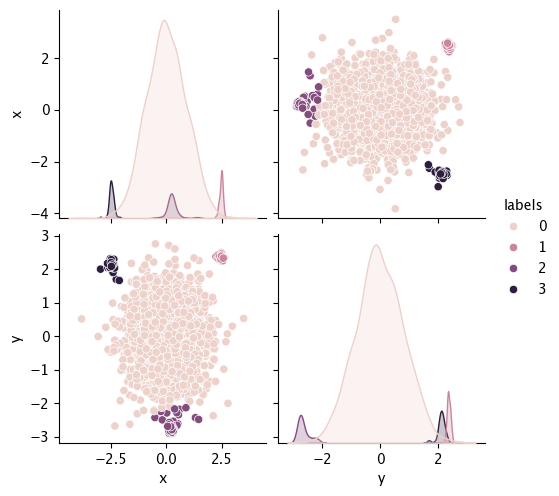

In [527]:
X = standardised_dataset_3_df.copy(['x', 'y']).copy()
X['labels'] = sp_model_3.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 19: `Spectral Clustering` Pairplot</center>*

However, when we visualise the data in `Figure 19` we can see that it has accurately segmented the main section of the data from the subsections around it.

### 3.9 Review the Results

#### 3.9.1 Visualising the Clusters

Let's plot a `scatter` diagram using the predicted labels generated by the `fit_predict` method. 

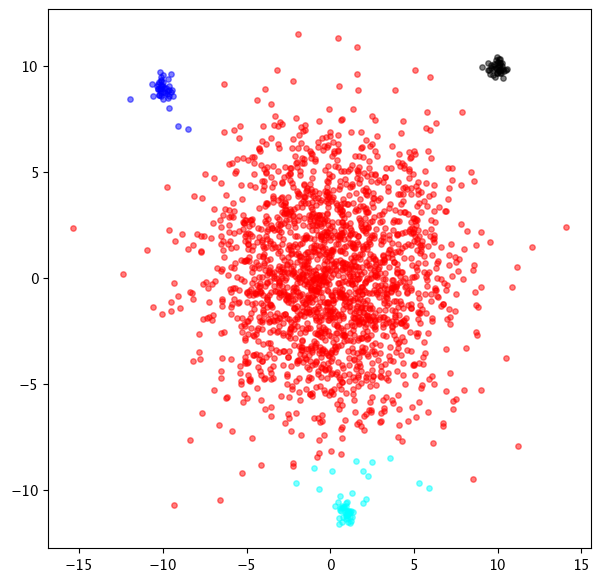

In [528]:
plt.figure(figsize=(7, 7))

y_spectral_3 = sp_model_3.fit_predict(standardised_dataset_3_df)

plt.scatter(dataset_3.loc[y_spectral_3==0]['x'], dataset_3.loc[y_spectral_3==0]['y'], s=15, c='red', alpha=.5)
plt.scatter(dataset_3.loc[y_spectral_3==1]['x'], dataset_3.loc[y_spectral_3==1]['y'], s=15, c='black', alpha=.5)
plt.scatter(dataset_3.loc[y_spectral_3==2]['x'], dataset_3.loc[y_spectral_3==2]['y'], s=15, c='blue', alpha=.5)
plt.scatter(dataset_3.loc[y_spectral_3==3]['x'], dataset_3.loc[y_spectral_3==3]['y'], s=15, c='cyan', alpha=.5)

plt.show()

*<center>Figure 20: `Spectral Clustering` Visualisation</center>*

Sure enough, we can see that the `Spectral Clustering` algorithm has appropriately separated the middle portion of the underlying dataset and grouped the smaller distributions into separate clusters.

Again, using visual data in combinbation with various scores has allowed us to find a clustering algorithm that suits the scenario.

## 4. `dataset_4.csv`

### 4.1 Introduction

Now we can explore the last dataset, which is represented in `dataset_4.csv`.

### 4.2 Load the Required Libraries

In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn import preprocessing, metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, HDBSCAN, SpectralClustering
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

### 4.3 Load the Data into a Dataframe

We start by loading the dataset into `dataset_4`.

In [531]:
dataset_4 = pd.read_csv('CML_2026-04-27#6-dataset4.csv')
dataset_4

,x,y
0,0.27320,0.63675
1,-0.45473,0.87376
2,-0.64651,0.78376
3,1.19074,0.15812
4,0.30047,0.52836
...,...,...
1095,-2.55293,-6.97416
1096,2.93280,-7.26317
1097,3.35595,-6.94712
1098,3.02931,-6.88218


### 4.4 Clean the Data

#### 4.4.1 Missing Data Visualisation

In [532]:
print(f'Missing null counts = \n{dataset_4.isnull().sum()}')

Missing null counts = 
x    0
y    0
dtype: int64


The output of `dataset_4.isnull().sum()` indicates that there aren't any missing data points, which is good.

#### 4.4.2 Format Decimal Places

In [533]:
pd.set_option('display.float_format', '{:.5f}'.format)

In [534]:
dataset_4

,x,y
0,0.27320,0.63675
1,-0.45473,0.87376
2,-0.64651,0.78376
3,1.19074,0.15812
4,0.30047,0.52836
...,...,...
1095,-2.55293,-6.97416
1096,2.93280,-7.26317
1097,3.35595,-6.94712
1098,3.02931,-6.88218


Let's set the number of decimal places to `5` again for ease of computation.

#### 4.4.3 Standardise the Data

Finally, let's standardise the dataset by calling `preprocessing`'s `scale()` method.

In [535]:
standardised_dataset_4 = preprocessing.scale(dataset_4)
standardised_dataset_4_df = pd.DataFrame(standardised_dataset_4, columns=dataset_4.columns)
standardised_dataset_4_df

,x,y
0,0.12551,0.71430
1,-0.22363,0.78075
2,-0.31562,0.75552
3,0.56560,0.58010
4,0.13859,0.68391
...,...,...
1095,-1.23002,-1.41965
1096,1.40116,-1.50069
1097,1.60412,-1.41207
1098,1.44745,-1.39386


### 4.5 Select Clustering Algorithms

Our dataset is now ready to be visualised by calling the `scatter_matrix` method. This can give us insight into the relationship between the feature variables.

#### 4.5.1 Visualise the Data

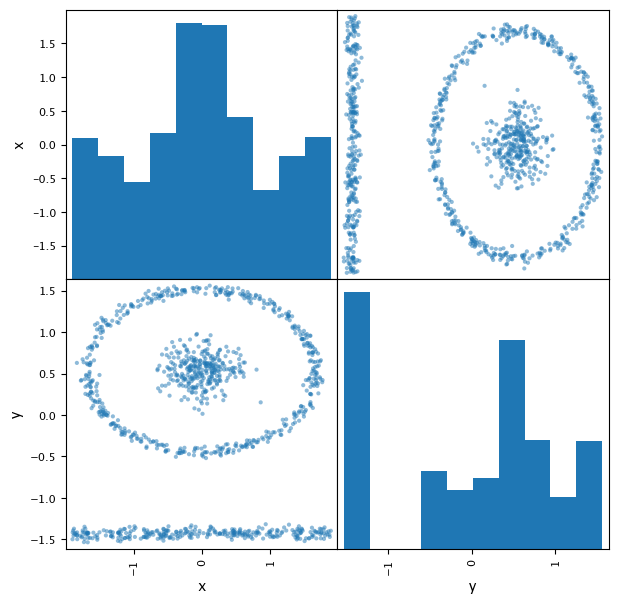

In [536]:
%matplotlib inline

scatter_matrix(standardised_dataset_4_df, figsize=(7, 7))

plt.show()

*<center>Figure 21: Scatter Matrix Visualisation</center>*

Looking at `Figure 21` we can see a few structures: a line, and a circle with a blob and some noise. There are several clustering techniques that spring to mind:

- `Spectral Clustering`
- `OPTICS`
- `DBSCAN`

### 4.6 Spectral Clustering

#### 4.6.1 Build the Model

Starting with `Spectral Clustering`, we can set leave `n_clusters` set to `4`:

In [ ]:
def sp_clustering_model(X):
    sp_model = SpectralClustering(n_clusters=4)
    sp_model.fit(X)

    labels = sp_model.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return sp_model

sp_model_4 = sp_clustering_model(standardised_dataset_4_df)

labels = [0 0 0 ... 1 1 2]
label_set = {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
label_list[0:10] = [np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0)]
noise_point_count = 0


When we run the `sp_clustering_model()` method with `dataset_4` we can see that it has clustered the data into four groups and has not identified any noise within the data.

#### 4.6.2 Generate Scores

In [596]:
spectral_4_labels = sp_model_4.fit_predict(standardised_dataset_4_df)

print(f'Silhouette Score: {silhouette_score(standardised_dataset_4_df, spectral_4_labels):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(standardised_dataset_4_df, spectral_4_labels):.4f}')

Silhouette Score: 0.4207
Davies-Bouldin Index: 0.7008


The `silhouette_score` seems relatively high, indicated it could be well separated.

#### 4.6.3 Visualise the Data

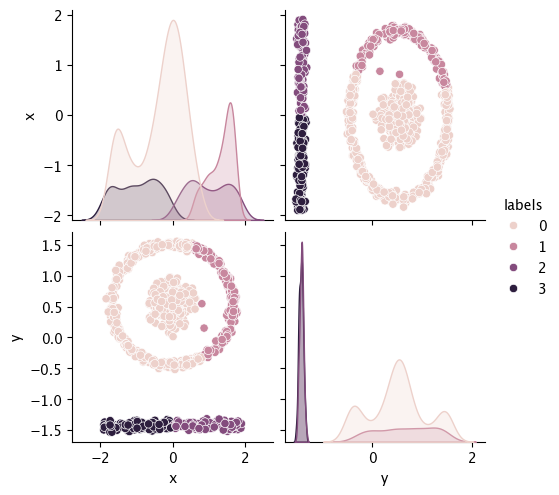

In [599]:
X = standardised_dataset_4_df.copy(['x', 'y']).copy()
X['labels'] = sp_model_4.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 22: `Spectral Clustering` Pairplot</center>*

However, looking at the data we can see that while it separates it well, it hasn't split the data into the shapes we identified in the previous section.

### 4.7 OPTICS

#### 4.7.1 Build the Model

Now let's explore using the `OPTICS` model, keeping the `min_samples` set to `50`.

In [569]:
optics_4 = optics_model(standardised_dataset_4_df)

labels = [0 0 0 ... 3 3 4]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 465


The `OPTICS` model indicates that the group has been clustered into four groups and identified `465` noise points within the underlying dataset.

#### 4.7.2 Generate Scores

In [570]:
optics_4_labels = np.ravel(optics_4.labels_).astype(int)

print(f'OPTICS Score: {silhouette_score(standardised_dataset_4_df, optics_4_labels)}')

OPTICS Score: 0.23043064319202114


The score is pretty high, even though it is slightly lower than that of the `Spectral Clustering` algorithm.

#### 4.7.3 Visualise the Data

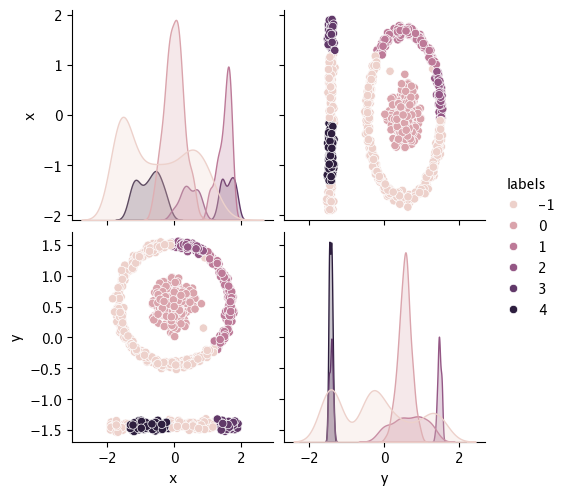

In [571]:
X = standardised_dataset_4_df.copy(['x', 'y']).copy()
X['labels'] = optics_4.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 23: `OPTICS` Pairplot</center>*

However, looking at the visualisation in `Figure 23` it's evident that it doesn't cluster the dataset as desired.

### 4.8 DBSCAN

#### 4.8.1 Build the Model

Now if we call `dbscan_model()` with the default `episilon` that has been used throughout this workbook:

In [572]:
dbscan_4 = dbscan_model(standardised_dataset_4_df)

labels = [0 0 0 ... 1 1 1]
label_set = {np.int64(0), np.int64(1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 0


The output of the method indicates that the algorithm has only classified the underlying data into two groups, without discovering any noise points.

#### 4.8.2 Generate Silhouette Score

In [573]:
dbscan_4_labels = np.ravel(dbscan_4.labels_).astype(int)

print(f'DBSCAN Score: {silhouette_score(standardised_dataset_4_df, dbscan_4_labels)}')

DBSCAN Score: 0.4273381063001043


Which the `silhouette_score` has interpreted as being well separated.

#### 4.8.3 Visualise the Data

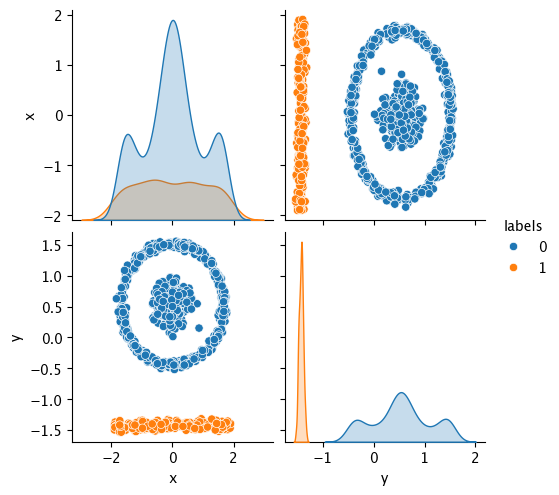

In [574]:
X = standardised_dataset_4_df.copy(['x', 'y']).copy()
X['labels'] = dbscan_4.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 24: `DBSCAN` Pairplot (`eps=0.5`)</center>*

And looking at the data we can see that the algorithm has actually done quite a good job at separating out the data, it just seems to cast too wide a net in identifying neighboring datapoints.

#### 4.8.4 Update `epsilon`

This can be resolved by lowering the `epsilon` value from `0.5` to `0.3`. This tells the algorithm to lower the distance which is used for clustering assignments.

In [575]:
def dbscan_4_model(X):
    dbscan = DBSCAN(eps=0.3)
    dbscan.fit(X)

    labels = dbscan.labels_
    print(f'labels = {labels}')

    label_set = set(labels)
    print(f'label_set = {label_set}')

    label_list = list(labels)
    print(f'label_list[0:10] = {label_list[0:10]}')

    noise_point_count = label_list.count(-1)
    print(f'noise_point_count = {noise_point_count}')

    return dbscan

dbscan_4 = dbscan_4_model(standardised_dataset_4_df)

labels = [0 0 0 ... 2 2 2]
label_set = {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
label_list[0:10] = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
noise_point_count = 1


Sure enough, we can see that the algorithm has increased the number of groups that have been identified as well as identified a noise point!

#### 4.8.5 Regenerate Scores

In [576]:
dbscan_4_labels = np.ravel(dbscan_4.labels_).astype(int)

print(f'DBSCAN Score: {silhouette_score(standardised_dataset_4_df, dbscan_4_labels)}')

DBSCAN Score: 0.07375648586903863


While the `silhouette_score` seems to be much lowered, we can study the underlying data visually to better understand the clustering applied.

#### 4.8.5 Visualise the Data

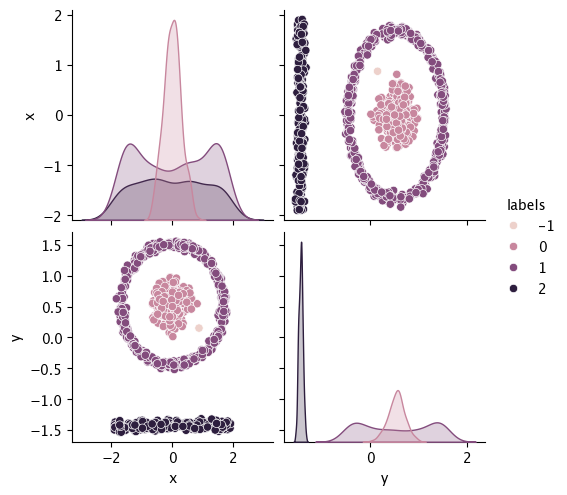

In [577]:
X = standardised_dataset_4_df.copy(['x', 'y']).copy()
X['labels'] = dbscan_4.labels_
sns.pairplot(X, hue='labels')

plt.show()

*<center>Figure 25: `DBSCAN` Pairplot (`eps=0.3`)</center>*

Sure enough, it identified the clusters perfectly! We have the line as well as a circle and its internal datapoints, as well as the noise point.

### 4.9 Review the Results

If we plot each of the clusters as well as the noise point into a `scatter diagram`, we can see our final clusterings in better detail.

> Note: The `x` and `y` variables have been flipped so the diagram is shown on its side.

#### 4.9.1 Visualising the Clusters

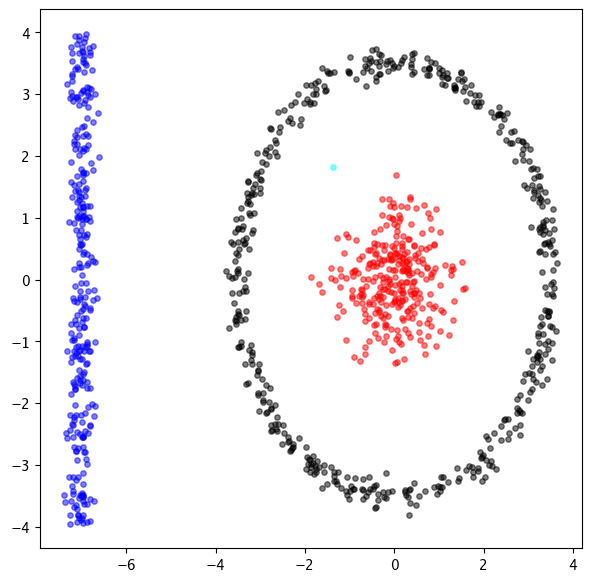

In [579]:
plt.figure(figsize=(7, 7))

y_dbscan_4 = dbscan_4.fit_predict(standardised_dataset_4_df)

plt.scatter(dataset_4.loc[y_dbscan_4==0]['y'], dataset_4.loc[y_dbscan_4==0]['x'], s=15, c='red', alpha=.5)
plt.scatter(dataset_4.loc[y_dbscan_4==1]['y'], dataset_4.loc[y_dbscan_4==1]['x'], s=15, c='black', alpha=.5)
plt.scatter(dataset_4.loc[y_dbscan_4==2]['y'], dataset_4.loc[y_dbscan_4==2]['x'], s=15, c='blue', alpha=.5)
plt.scatter(dataset_4.loc[y_dbscan_4==-1]['y'], dataset_4.loc[y_dbscan_4==-1]['x'], s=15, c='cyan', alpha=.5)

plt.show()

*<center>Figure 26: `DBSCAN` Visualisation</center>*

We can see from looking at `Figure 26` that the `DBSCAN` clustering algorithm with `epsilon` set to `0.3` has appropriately separated out the individual shapes as well as correctly identified the single noise point that sits as an outlier to the inner group within the circle and the radius of the circle itself.

## A. Appendix

### A.1 References

1. Accuracy of decimal places in latitude and longitude degrees: Garmin Customer Support (no date) Garmin. Available at: [https://support.garmin.com/en-US/?faq=hRMBoCTy5a7HqVkxukhHd8](https://support.garmin.com/en-US/?faq=hRMBoCTy5a7HqVkxukhHd8) (Accessed: 24 May 2026).
1. R. Collins, 'Classical Machine Learning v12' [PDF Slides], CML: Classical Machine Learning, University of Oxford, April 20 2026, [https://drive.google.com/file/d/1V0gkCj7rF6CF2l1-HteD9hN3f5FMwBwC/view?usp=drive_link](https://drive.google.com/file/d/1V0gkCj7rF6CF2l1-HteD9hN3f5FMwBwC/view?usp=drive_link) (Accessed: 24 May 2026).
1. HDBSCAN: scikit-learn Documentation. Available at [https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html) (Accessed: 24 May 2026).
1. davies_bouldin_score: scikit-learn Documentation, Available at [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html) (Accessed: 25 May 2026)
1. GaussianMixture: scikit-learn Documentation, Available at [https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) (Accessed: 25 May 2026)